# Pre processing

In [ ]:
def txt_to_ply(txt_path, ply_path):
    with open(txt_path, "r") as f:
        rows = [line.strip().split() for line in f if line.strip()]

    with open(ply_path, "w") as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(rows)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write("property float nx\n")
        f.write("property float ny\n")
        f.write("property float nz\n")
        f.write("property uchar red\n")
        f.write("property uchar green\n")
        f.write("property uchar blue\n")
        f.write("end_header\n")

        for r in rows:
            if len(r) != 9:
                raise ValueError(f"Expected 9 values per row, got {len(r)}")

            f.write(" ".join(r) + "\n")

In [2]:
txt_to_ply("/home/jelle-vermandere/Documents/Github/DRM/_input/ChairPartialPcd.txt","/home/jelle-vermandere/Documents/Github/DRM/_input/ChairPartialPcd.ply")

## Pano alignment

In [1]:
import numpy as np
from PIL import Image

# Path to your point cloud TXT file
pointcloud_file = "/home/jvermandere/projects/DRM/_input/Office2.txt"
pano_file = "/home/jvermandere/projects/DRM/_input/Office2.png"

# --- Load equirectangular image ---
pano = Image.open(pano_file).convert("RGB")
width, height = pano.size
img = np.array(pano)

# --- Read transform matrix from the file ---
with open(pointcloud_file, "r") as f:
    lines = f.readlines()

# Find the line that starts the matrix
matrix_start = None
for i, line in enumerate(lines):
    if line.startswith("# transform_matrix"):
        matrix_start = i + 1
        break

if matrix_start is None:
    raise ValueError("Transform matrix not found in file.")

# Read 4x4 matrix

transformationMartix = np.fromstring(lines[matrix_start][2:], dtype=float, sep=' ').reshape((4,4))
print(transformationMartix)

# --- Read point cloud (skip comments) ---
points = np.loadtxt(pointcloud_file, comments="#")  # shape (N, 9): x y z nx ny nz r g b

print(points.shape)
# Extract positions and colors
xyz = points[:, :3]
rgb = points[:, 6:9]


[[ 1.    0.    0.   -0.02]
 [ 0.    1.    0.    2.54]
 [ 0.    0.    1.   -1.38]
 [ 0.    0.    0.    1.  ]]
(77302, 9)


In [2]:
import numpy as np
def rotate_y_90_degrees():
    """
    Returns a 4x4 homogeneous rotation matrix for 90-degree rotation around y-axis.
    """
    theta = -np.pi / 2  # 90 degrees in radians
    R = np.array([
        [np.cos(theta), 0, np.sin(theta), 0],
        [0, 1, 0, 0],
        [-np.sin(theta), 0, np.cos(theta), 0],
        [0, 0, 0, 1]
    ])
    return R
def transform_points_and_xyz_to_uv(points, tMat):
    """
    Apply a 4x4 transform matrix to 3D points and convert to equirectangular UV.

    Args:
        points: numpy array of shape (N,3) where each row is [x, y, z]
        T: 4x4 transformation matrix

    Returns:
        uv: numpy array of shape (N,2) with [u,v] coordinates in [0,1]
    """
    N = points.shape[0]

    # Convert to homogeneous coordinates (N,4)
    points_h = np.hstack([points, np.ones((N, 1))])

    # Apply transformation (matrix multiplication)
    points_cam_h = (rotate_y_90_degrees() @ points_h.T).T#(np.linalg.inv(tMat) @ points_h.T).T  # shape (N,4)

    # Convert back to 3D (ignore w, assuming affine transform)
    points_cam = points_cam_h[:, :3] - np.repeat([[-tMat[2,3],tMat[1,3],tMat[0,3]]],N,axis = 0) # np.repeat([[tMat[0,3],tMat[1,3],tMat[2,3]]],N,axis = 0)

    # --- Convert transformed points to equirectangular UV ---
    x = points_cam[:, 0]
    y = points_cam[:, 1]
    z = points_cam[:, 2]

    r = np.linalg.norm(points_cam, axis=1)
    r[r == 0] = 1  # avoid division by zero

    theta = np.arccos(y / r)    # polar angle
    phi = np.arctan2(z, x)      # azimuthal angle

    u = (phi + np.pi) / (2 * np.pi)
    v = theta / np.pi

    # Handle origin points safely
    zero_mask = r == 0
    u[zero_mask] = 0.5
    v[zero_mask] = 0.5

    return np.stack([1-u, v], axis=1)

uv_coords = transform_points_and_xyz_to_uv(xyz, transformationMartix)
print(uv_coords.min())
print(uv_coords.max())

0.0
1.0


In [5]:
for coord in uv_coords:
    u = int(coord[0] * width) -1
    v = int(coord[1] * height)
    print(u,v)
    img[v, u] = [int(255), int(0), int(0)]
overlay = Image.fromarray(img)

2047 913
2 913
5 913
8 913
12 913
15 913
18 913
21 913
25 913
28 913
31 913
34 913
38 913
41 913
44 913
47 913
51 913
54 913
57 913
60 913
64 913
67 913
70 913
73 913
77 913
80 913
83 913
87 913
90 913
93 913
96 913
100 913
103 913
106 913
109 913
113 913
116 913
119 913
122 913
126 913
129 913
132 913
135 913
139 913
142 913
145 913
148 913
152 913
155 913
158 913
161 913
165 913
168 913
171 913
175 913
178 913
181 913
184 913
188 913
191 913
194 913
197 913
201 913
204 913
207 913
210 913
214 913
217 913
220 913
223 913
227 913
230 913
233 913
236 913
240 913
243 913
246 913
249 913
253 913
256 913
259 913
263 913
266 913
269 913
272 913
276 913
279 913
282 913
285 913
289 913
292 913
295 913
298 913
302 913
305 913
308 913
311 913
315 913
318 913
321 913
324 913
328 913
331 913
334 913
337 913
341 913
344 913
347 913
351 913
354 913
357 913
360 913
364 913
367 913
370 913
373 913
377 913
380 913
383 913
386 913
390 913
393 913
396 913
399 913
403 913
406 913
409 913
412 913
416 913


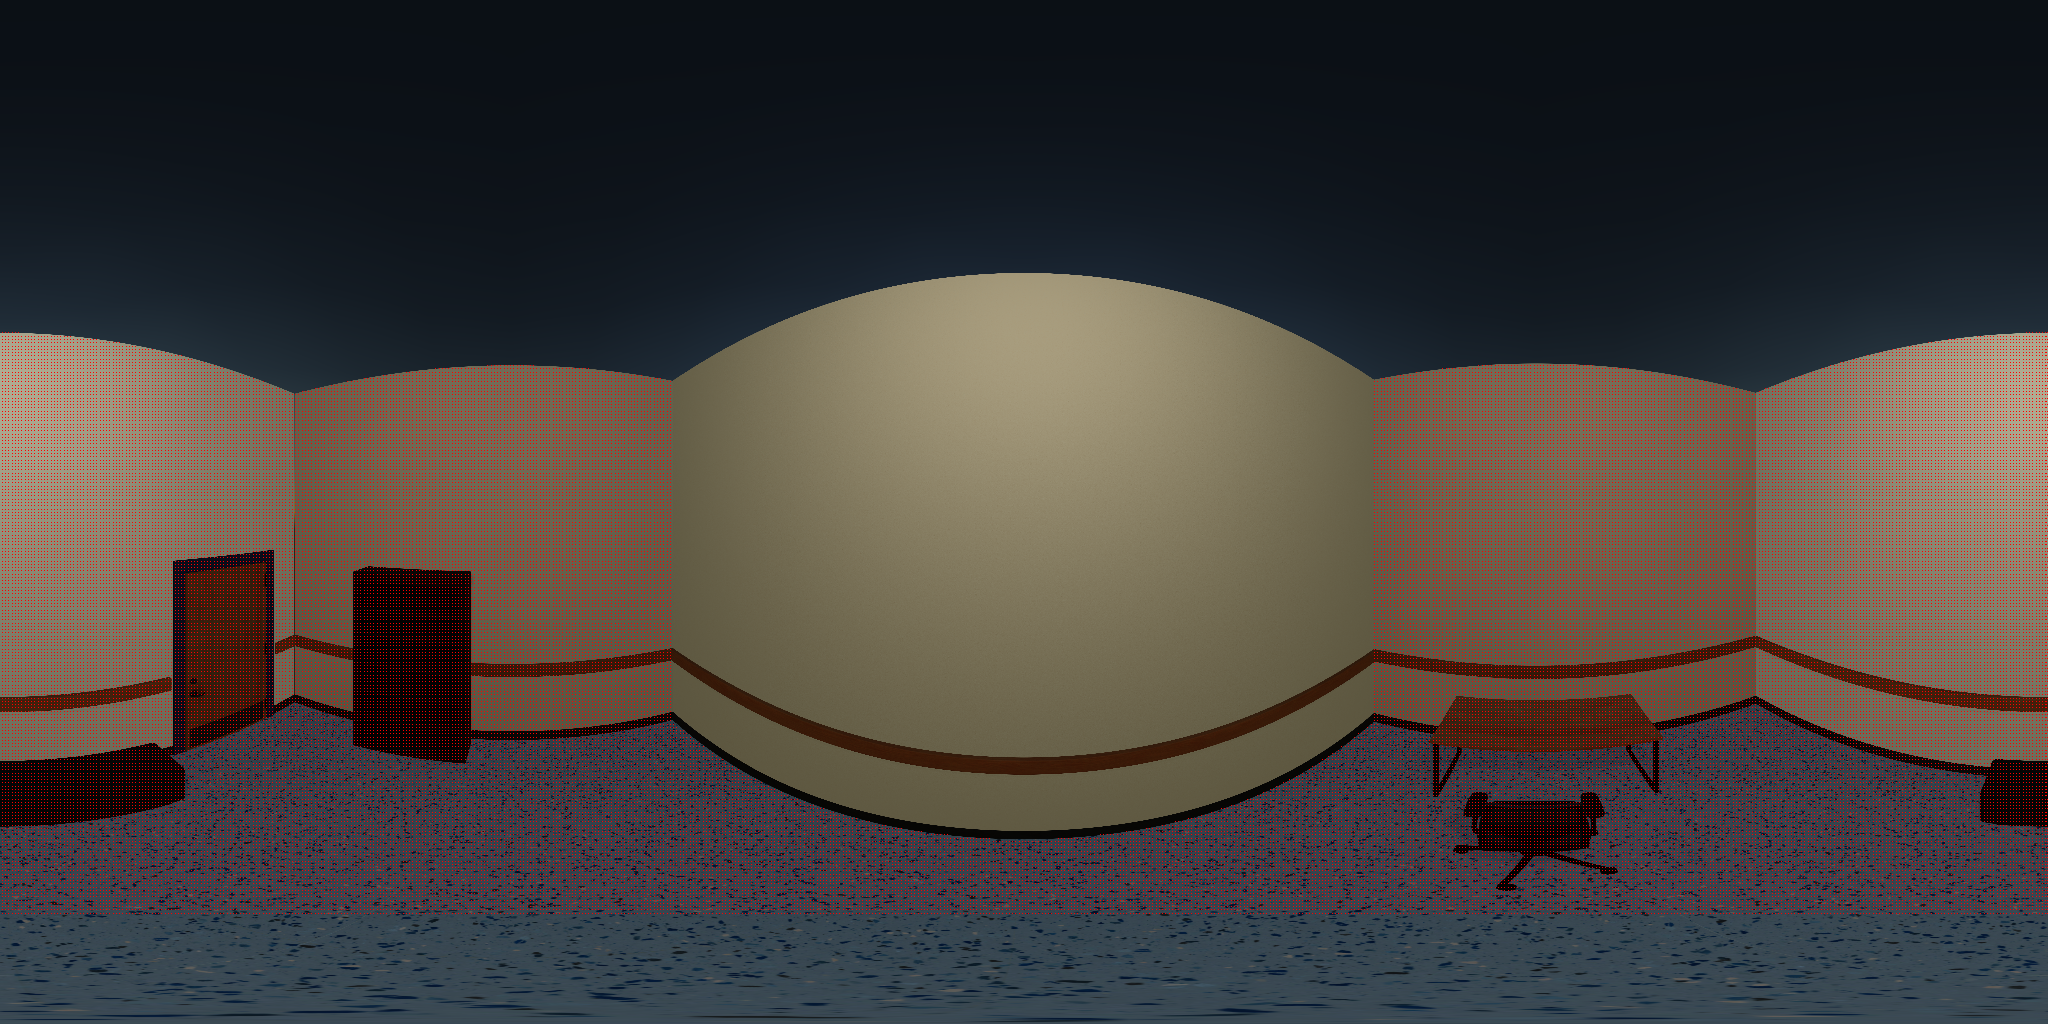

In [6]:
overlay